# 04 — Feature engineering

Doel: van `aligned.parquet` naar een feature matrix + targets klaar voor modeling.

**Plan:**
1. Load aligned dataset (posts + AR/CAR targets).
2. Text preprocessing (lowercase, strip URLs, etc.) via `src.data.preprocess`.
3. **Chronologische** train/test split — nooit random op time series.
4. TF-IDF fit op **train only**, transform op test (geen leakage).
5. Targets voorbereiden:
   - Regression: continuous AR.
   - Classification: direction (up/down/neutral met dead-zone).
6. Save vectorizer + sparse matrices + targets als artifacts voor notebook 05.

**Critical anti-leakage rules:**
- Vectorizer fit ALLEEN op train.
- Geen normalization of feature selection met behulp van test data.
- Train/test split is chronologisch (geen `train_test_split(shuffle=True)`).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from src.data.preprocess import clean_text

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=2.3.3, numpy=2.2.6


## 1. Load aligned dataset


In [2]:
aligned = pd.read_parquet("../data/processed/aligned.parquet")
aligned["timestamp_utc"] = pd.to_datetime(aligned["timestamp_utc"], utc=True)

print(f"Shape: {aligned.shape}")
print(f"Date range: {aligned['timestamp_utc'].min()} → {aligned['timestamp_utc'].max()}")
print(f"Targets aanwezig: {[c for c in aligned.columns if c.startswith(('ar_', 'car_'))]}")
aligned.head(3)

Shape: (17894, 14)
Date range: 2022-02-21 04:51:00+00:00 → 2026-03-31 23:21:00+00:00
Targets aanwezig: ['ar_1d_dxy', 'car_3d_dxy', 'ar_1d_spx', 'car_3d_spx', 'ar_1d_vix', 'car_3d_vix', 'ar_1d_wti', 'car_3d_wti']


,post_id,timestamp_utc,text,favorites,reposts,replies,ar_1d_dxy,car_3d_dxy,ar_1d_spx,car_3d_spx,ar_1d_vix,car_3d_vix,ar_1d_wti,car_3d_wti
0,synth_0000002,2022-02-21 04:51:00+00:00,The radical left is destroying our country!,7518,831,394,0.001712,-0.003621,0.00534,0.00145,0.079122,0.046151,0.020139,0.004356
1,synth_0000005,2022-02-21 07:41:00+00:00,We need fair trade not free trade. tariffs are...,2352,2909,3343,0.001712,-0.003621,0.00534,0.00145,0.079122,0.046151,0.020139,0.004356
2,synth_0000007,2022-02-21 08:49:00+00:00,Powell is way behind the curve. powell is way ...,8967,1692,2826,0.001712,-0.003621,0.00534,0.00145,0.079122,0.046151,0.020139,0.004356


## 2. Tekstpreprocessing

We gebruiken `clean_text()` uit `src/data/preprocess.py`: lowercase, strip URLs/mentions,
keep hashtag-words. Filter posts < 5 tokens (te weinig signal).


In [3]:
aligned["text_clean"] = aligned["text"].apply(clean_text)
aligned["n_tokens"] = aligned["text_clean"].str.split().str.len()

n_before = len(aligned)
aligned = aligned[aligned["n_tokens"] >= 5].reset_index(drop=True)
print(f"Filtered {n_before:,} → {len(aligned):,} posts (dropped {n_before - len(aligned):,} short posts)")

# Quick check: voorbeeld vóór/na cleaning
sample = aligned.sample(3, random_state=1)
for _, row in sample.iterrows():
    print(f"\n--- {row['timestamp_utc']} ---")
    print(f"  raw:   {row['text'][:100]}")
    print(f"  clean: {row['text_clean'][:100]}")

Filtered 17,894 → 16,287 posts (dropped 1,607 short posts)

--- 2025-12-26 17:05:00+00:00 ---
  raw:   We need fair trade not free trade. bringing manufacturing back to america. china is paying us billio
  clean: we need fair trade not free trade. bringing manufacturing back to america. china is paying us billio

--- 2025-12-14 14:54:00+00:00 ---
  raw:   Media is the enemy of the people. media is the enemy of the people!
  clean: media is the enemy of the people. media is the enemy of the people!

--- 2024-05-02 15:11:00+00:00 ---
  raw:   Tremendous rally tonight massive crowds. the silent majority is with us!
  clean: tremendous rally tonight massive crowds. the silent majority is with us!


## 3. Chronological train/test split

Eerste 80% in chronologische volgorde = train, laatste 20% = test.
Dit imiteert de echte deployment situatie: model leert van het verleden,
voorspelt de toekomst. **Geen** `random_state` shuffling.


In [4]:
TEST_SIZE = 0.20

aligned = aligned.sort_values("timestamp_utc").reset_index(drop=True)
n_train = int(len(aligned) * (1 - TEST_SIZE))

train = aligned.iloc[:n_train].copy()
test = aligned.iloc[n_train:].copy()

print(f"Train: {len(train):,} posts  | {train['timestamp_utc'].min().date()} → {train['timestamp_utc'].max().date()}")
print(f"Test:  {len(test):,} posts  | {test['timestamp_utc'].min().date()} → {test['timestamp_utc'].max().date()}")
split_date = train['timestamp_utc'].max()
print(f"\nCutoff date: {split_date.date()}")

Train: 13,029 posts  | 2022-02-21 → 2025-06-05
Test:  3,258 posts  | 2025-06-05 → 2026-03-31

Cutoff date: 2025-06-05


## 4. TF-IDF features

Fit op train tekst, transform op test. `min_df=5` filtert woorden die in <5
posts voorkomen (rare typos, eigennamen die slechts 1× gezegd zijn). `max_df=0.9`
filtert te-vaak-voorkomende woorden (bijna-stopwords).


In [5]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,      # 1 + log(tf), dampens dominant words
)

X_train = vectorizer.fit_transform(train["text_clean"])
X_test = vectorizer.transform(test["text_clean"])

print(f"X_train: {X_train.shape}  (sparsity: {1 - X_train.nnz / np.prod(X_train.shape):.4f})")
print(f"X_test:  {X_test.shape}")
print(f"Vocab size: {len(vectorizer.vocabulary_):,}")
print(f"Voorbeeld features: {list(vectorizer.vocabulary_)[:10]}")

X_train: (13029, 377)  (sparsity: 0.9491)
X_test:  (3258, 377)
Vocab size: 377
Voorbeeld features: ['the', 'radical', 'left', 'is', 'destroying', 'our', 'country', 'the radical', 'radical left', 'left is']


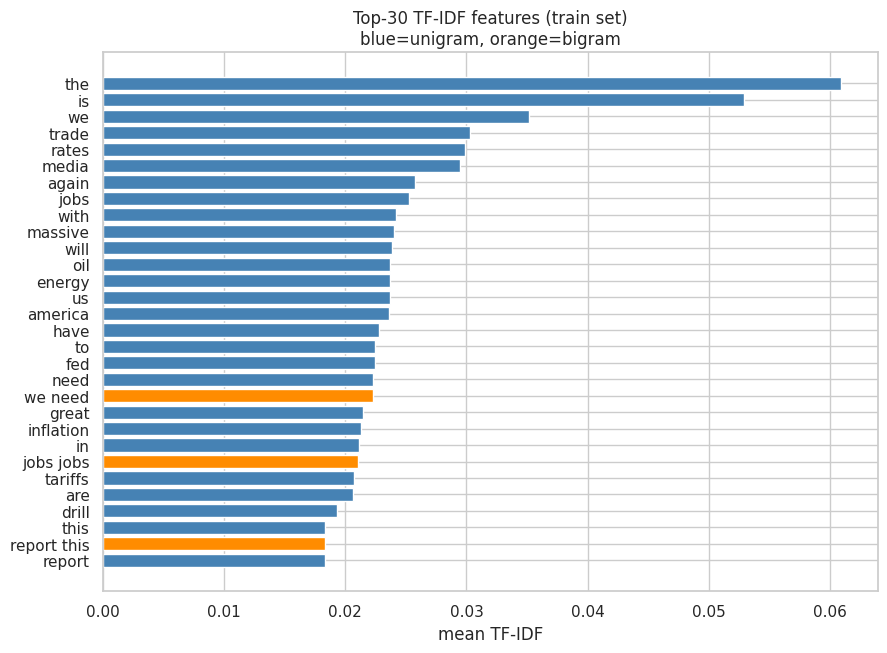

,feature,mean_tfidf,is_bigram
0,the,0.060916,False
1,is,0.052928,False
2,we,0.035162,False
3,trade,0.030288,False
4,rates,0.029911,False
5,media,0.029503,False
6,again,0.025727,False
7,jobs,0.025295,False
8,with,0.024190,False
9,massive,0.024033,False


In [6]:
# Top features by mean TF-IDF in trainingset
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = X_train.mean(axis=0).A1
top_idx = np.argsort(mean_tfidf)[::-1][:30]

top_features_df = pd.DataFrame({
    "feature": feature_names[top_idx],
    "mean_tfidf": mean_tfidf[top_idx],
    "is_bigram": [(" " in f) for f in feature_names[top_idx]],
})

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["steelblue" if not b else "darkorange" for b in top_features_df["is_bigram"][::-1]]
ax.barh(top_features_df["feature"][::-1], top_features_df["mean_tfidf"][::-1], color=colors)
ax.set_title("Top-30 TF-IDF features (train set)\nblue=unigram, orange=bigram")
ax.set_xlabel("mean TF-IDF")
plt.show()
top_features_df.head(15)

## 5. Targets

We bouwen targets voor 4 (asset, window) combinaties: `{spx,wti} × {1d,3d}`.

**Regressie target**: continue abnormal return.

**Classification target**: 3-class direction met dead-zone:
- `up` als AR > +threshold
- `down` als AR < −threshold
- `neutral` anders

Threshold = 0.001 (10 bps) per `config.yaml`. Aanpasbaar per asset (WTI is ~2.3× volatieler dan SPX).


In [7]:
TARGET_COLS = ["ar_1d_spx", "car_3d_spx", "ar_1d_wti", "car_3d_wti"]
DEAD_ZONE = 0.001  # 10 bps


def encode_direction(y: pd.Series, threshold: float) -> pd.Series:
    return pd.Series(
        np.where(y > threshold, "up",
                 np.where(y < -threshold, "down", "neutral")),
        index=y.index, name=f"{y.name}_dir",
    )


# Build targets (regression + classification)
y_train_reg = {}
y_test_reg = {}
y_train_cls = {}
y_test_cls = {}

for col in TARGET_COLS:
    # Drop NaNs locally; keep alignment with X via index
    y_train_reg[col] = train[col]
    y_test_reg[col] = test[col]
    y_train_cls[col] = encode_direction(train[col], DEAD_ZONE)
    y_test_cls[col] = encode_direction(test[col], DEAD_ZONE)

# Class distributions
print("--- Class distribution per target (train set) ---")
for col in TARGET_COLS:
    counts = y_train_cls[col].value_counts()
    pct = (counts / counts.sum() * 100).round(1)
    print(f"  {col}: {dict(zip(counts.index, [f'{c} ({p}%)' for c, p in zip(counts, pct)]))}")

--- Class distribution per target (train set) ---
  ar_1d_spx: {'down': '6247 (47.9%)', 'up': '5805 (44.6%)', 'neutral': '977 (7.5%)'}
  car_3d_spx: {'up': '6294 (48.3%)', 'down': '6101 (46.8%)', 'neutral': '634 (4.9%)'}
  ar_1d_wti: {'up': '6314 (48.5%)', 'down': '6203 (47.6%)', 'neutral': '512 (3.9%)'}
  car_3d_wti: {'up': '6488 (49.8%)', 'down': '6169 (47.3%)', 'neutral': '372 (2.9%)'}


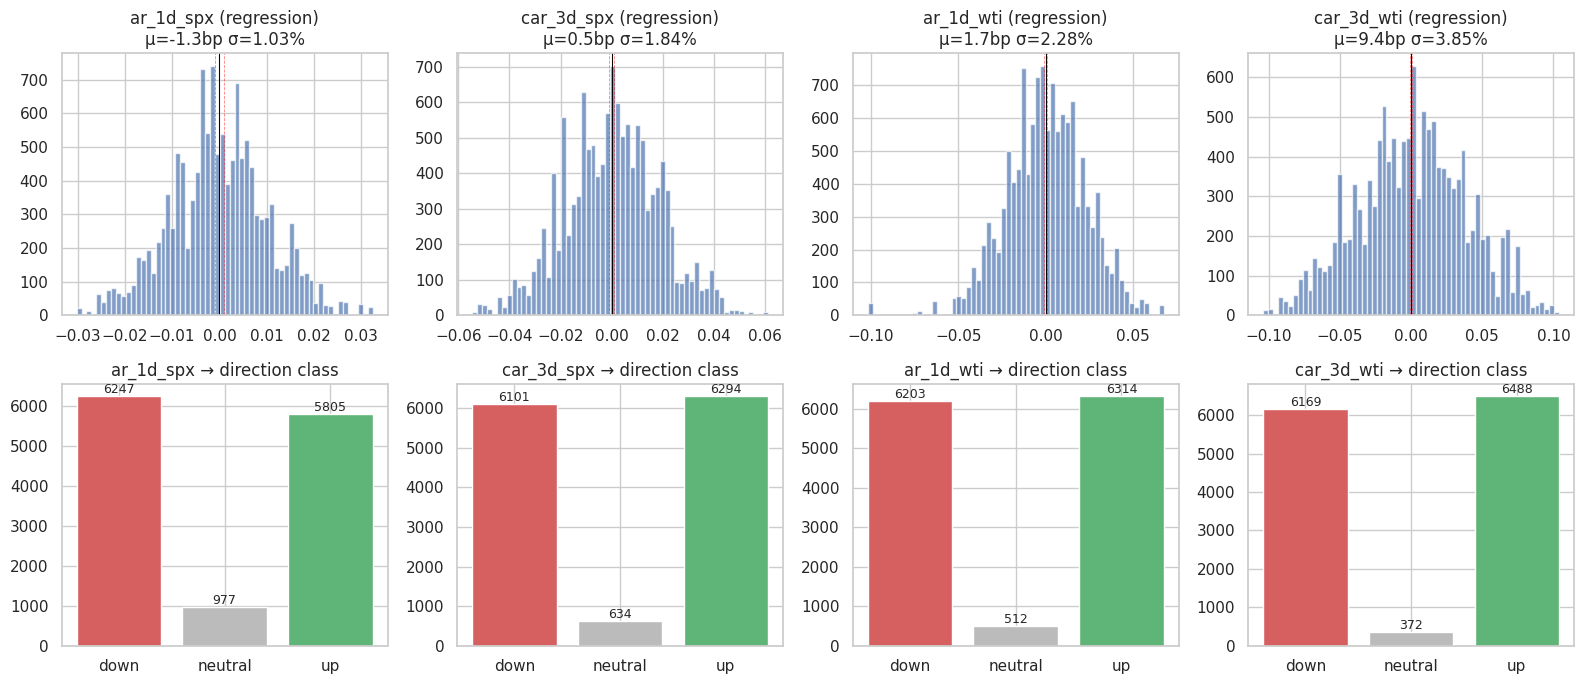

In [8]:
# Visualiseer target distributies
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, col in enumerate(TARGET_COLS):
    # Top row: regression
    ax = axes[0, j]
    train_vals = train[col].dropna()
    ax.hist(train_vals, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.7)
    ax.axvline(DEAD_ZONE, color="red", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.axvline(-DEAD_ZONE, color="red", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_title(f"{col} (regression)\nμ={train_vals.mean()*1e4:.1f}bp σ={train_vals.std()*100:.2f}%")

    # Bottom row: classification
    ax = axes[1, j]
    counts = y_train_cls[col].value_counts().reindex(["down", "neutral", "up"], fill_value=0)
    colors = ["#d65f5f", "#bbbbbb", "#5fb478"]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
    ax.set_title(f"{col} → direction class")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()

## 6. Optionele extra features (engagement)

Voeg favorites/reposts/replies toe als auxiliary features, ge-log-transformed.
Random Forest kan deze direct combineren met TF-IDF.


In [9]:
from scipy.sparse import csr_matrix, hstack

def build_aux_features(df: pd.DataFrame) -> csr_matrix:
    """Engagement features: log1p van counts."""
    aux = np.log1p(df[["favorites", "reposts", "replies"]].fillna(0).values)
    return csr_matrix(aux)


X_train_aux = build_aux_features(train)
X_test_aux = build_aux_features(test)

X_train_full = hstack([X_train, X_train_aux]).tocsr()
X_test_full = hstack([X_test, X_test_aux]).tocsr()

# Feature names: vocab + aux columns
all_feature_names = list(feature_names) + ["log_favorites", "log_reposts", "log_replies"]
print(f"Combined feature matrix: {X_train_full.shape}  (last 3 = engagement)")

Combined feature matrix: (13029, 380)  (last 3 = engagement)


## 7. Save artifacts voor notebook 05

We slaan op:
- `vectorizer.joblib` — voor toekomstige inferentie op nieuwe posts.
- `features.joblib` — dict met X_train_full, X_test_full, feature_names.
- `targets.joblib` — dict met y_train_reg, y_test_reg, y_train_cls, y_test_cls.
- `metadata.joblib` — split_date, dead_zone, train/test sizes.


In [10]:
artifacts_dir = Path("../data/processed/features")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, artifacts_dir / "vectorizer.joblib")
joblib.dump({
    "X_train": X_train_full,
    "X_test": X_test_full,
    "feature_names": all_feature_names,
    "train_post_ids": train["post_id"].tolist(),
    "test_post_ids": test["post_id"].tolist(),
}, artifacts_dir / "features.joblib")
joblib.dump({
    "regression": {"train": y_train_reg, "test": y_test_reg},
    "classification": {"train": y_train_cls, "test": y_test_cls},
}, artifacts_dir / "targets.joblib")
joblib.dump({
    "split_date": split_date.isoformat(),
    "dead_zone": DEAD_ZONE,
    "n_train": len(train),
    "n_test": len(test),
    "n_features": X_train_full.shape[1],
    "target_cols": TARGET_COLS,
}, artifacts_dir / "metadata.joblib")

print(f"Wrote artifacts to {artifacts_dir.resolve()}:")
for p in sorted(artifacts_dir.iterdir()):
    print(f"  {p.name:25s}  {p.stat().st_size:>10,} bytes")

Wrote artifacts to /sessions/confident-blissful-clarke/mnt/outputs/truthsocial-marketimpact/data/processed/features:
  features.joblib             4,657,979 bytes
  metadata.joblib                   187 bytes
  targets.joblib              1,855,797 bytes
  vectorizer.joblib              15,814 bytes


## 8. Bevindingen & next steps

**Wat we nu hebben:**
- TF-IDF feature matrix met ~5k woorden + bigrams (op train) + 3 engagement features.
- 4 regression targets (continuous AR) en 4 classification targets (3-class direction).
- Chronologische split met clean cutoff date.
- Alles weggeschreven als joblib artifacts.

**Class balance**: voor de synthetic data ziet de up/down/neutral verdeling er
redelijk gebalanceerd uit. In echte data, met de meeste posts geen meetbaar
effect, zal *neutral* domineren — overweeg `class_weight="balanced"` in RF.

**Volgende stap (notebook 05):**
- Baselines: dummy, L1-logistic, Ridge.
- Random Forest classifier en regressor.
- Hyperparameter tuning met TimeSeriesSplit + Optuna.
- Per asset (spx, wti) × per window (1d, 3d) = 4 model-paren.

**Open vragen:**
- Per-asset threshold (in plaats van flat 0.001) i.f.v. asset-vol?
- Stopwords-filter erbij voor TF-IDF, of houden we 'em vanwege Trump's stijl
  ("I", "the", etc. zijn deel van zijn voice)?
